In [1]:
import polars as pl
from plotnine import *
import re

theme_set(theme_bw())

In [2]:
# command for generating the s3_status.json file (it isn't actually JSON though, don't know why)
# aws s3 ls --output json s3://sandpiper-woodcrob/test/ >s3_status.json


# Preprocess the file
with open('s3_status.json', 'r') as file:
    content = file.read()

# Replace multiple delimiters with a single delimiter (e.g., ',')
content = re.sub(r' +', ' ', content)

# Write the preprocessed content to a temporary file
with open('/tmp/temp.csv', 'w') as temp_file:
    temp_file.write(content)

# Read the preprocessed file into Polars
df = pl.read_csv('/tmp/temp.csv')

s3 = pl.read_csv('/tmp/temp.csv', has_header=False, separator=' ')
s3[:3], s3[-3:]

(shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪══════════╪═════════════════════════════════╡
 │ 2025-02-25 ┆ 22:08:36 ┆ 26759    ┆ DRR001961.unannotated.singlem.… │
 │ 2025-02-26 ┆ 10:59:58 ┆ 60975    ┆ DRR003630.unannotated.singlem.… │
 │ 2025-02-23 ┆ 20:09:51 ┆ 45914    ┆ DRR003636.unannotated.singlem.… │
 └────────────┴──────────┴──────────┴─────────────────────────────────┘,
 shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪═══════

In [3]:
s3.columns = ['date', 'time', 'size','file']
s3[:3]

date,time,size,file
str,str,i64,str
"""2025-02-25""","""22:08:36""",26759,"""DRR001961.unannotated.singlem.…"
"""2025-02-26""","""10:59:58""",60975,"""DRR003630.unannotated.singlem.…"
"""2025-02-23""","""20:09:51""",45914,"""DRR003636.unannotated.singlem.…"


In [4]:
s3 = s3.with_columns(pl.col('file').str.split('.').list.get(0).alias('acc'))
# date and time are in separate columns, so we need to combine them into a single column datetime
s3 = s3.with_columns((pl.col('date') + ' ' + pl.col('time')).str.to_datetime("%Y-%m-%d %H:%M:%S").alias('datetime'))
s3[:3]

date,time,size,file,acc,datetime
str,str,i64,str,str,datetime[μs]
"""2025-02-25""","""22:08:36""",26759,"""DRR001961.unannotated.singlem.…","""DRR001961""",2025-02-25 22:08:36
"""2025-02-26""","""10:59:58""",60975,"""DRR003630.unannotated.singlem.…","""DRR003630""",2025-02-26 10:59:58
"""2025-02-23""","""20:09:51""",45914,"""DRR003636.unannotated.singlem.…","""DRR003636""",2025-02-23 20:09:51


In [5]:
# Original data
acc20k = pl.read_csv('runlists/acc_less_than_20k_mbytes.csv', has_header=False)
acc20k.columns = ['acc']
acc20k[:3]

df = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns.csv.gz', has_header=False)
df.columns = ['acc','releasedate','mbases','mbytes']
df[:4]

merged20k = acc20k.join(df, on='acc', how='inner')
merged20k[:3], merged20k.shape

(shape: (3, 4)
 ┌─────────────┬───────────────────────────┬────────┬────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    │
 │ str         ┆ str                       ┆ i64    ┆ i64    │
 ╞═════════════╪═══════════════════════════╪════════╪════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    │
 └─────────────┴───────────────────────────┴────────┴────────┘,
 (710928, 4))

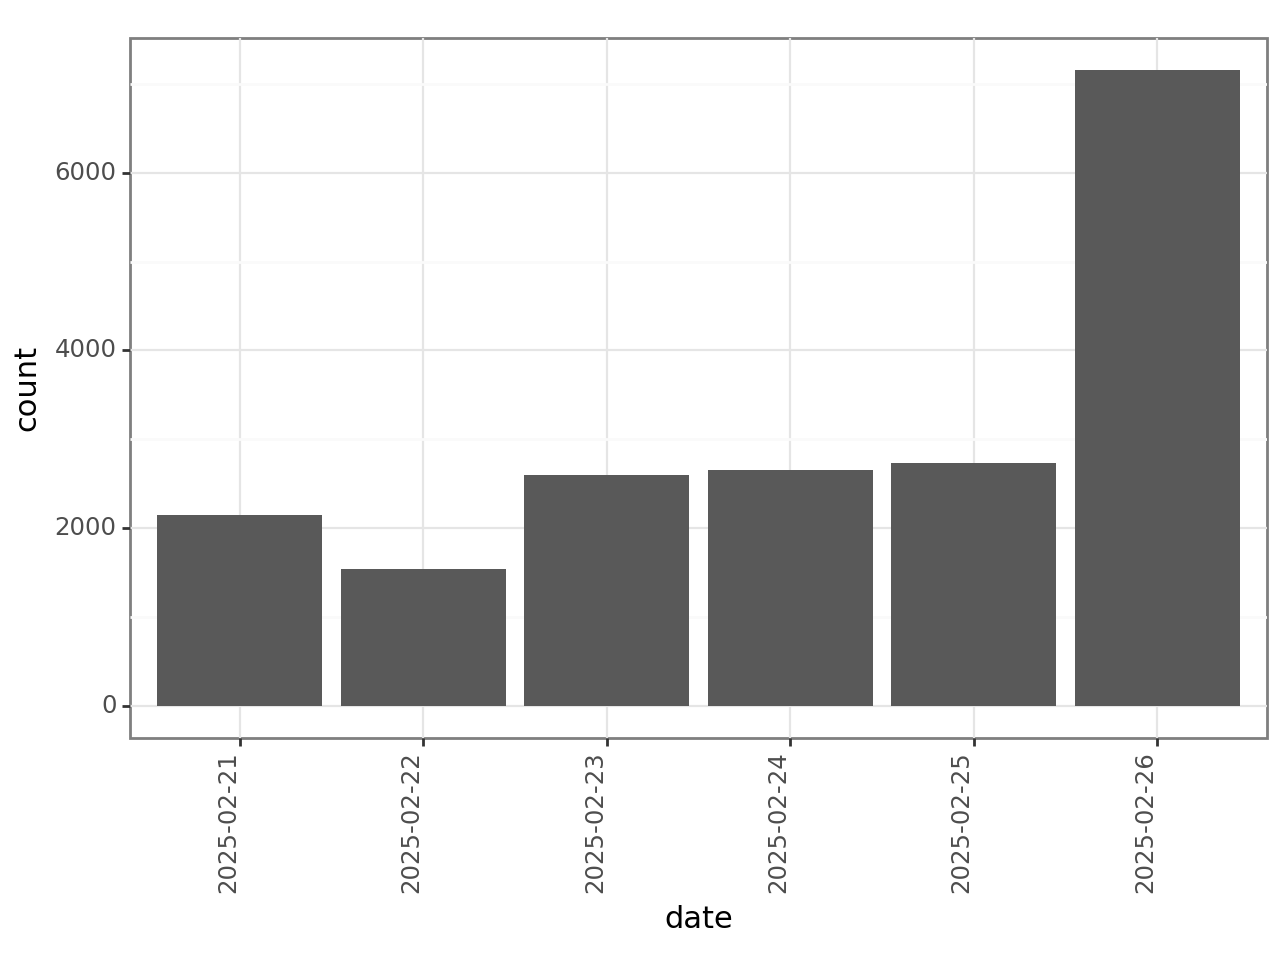

<Figure Size: (640 x 480)>

In [6]:
# plot number of acc finished per day
ggplot(data=s3)+geom_bar(aes(x='date'))+theme(axis_text_x=element_text(rotation=90, hjust=1))

In [7]:
# Are larger files being processed? Plot the number of files processed per day, colored by size
joined = merged20k.join(s3, on='acc', how='left')
joined.filter(pl.col('size')>0)[:3]

acc,releasedate,mbases,mbytes,date,time,size,file,datetime
str,str,i64,i64,str,str,i64,str,datetime[μs]
"""SRR30234901""","""2024-08-15T00:00:00+00:00""",8301,3561,"""2025-02-26""","""14:22:58""",1177291,"""SRR30234901.unannotated.single…",2025-02-26 14:22:58
"""ERR10083145""","""2022-08-16T00:00:00+00:00""",183,148,"""2025-02-24""","""06:14:08""",27642,"""ERR10083145.unannotated.single…",2025-02-24 06:14:08
"""ERR9187151""","""2022-03-12T00:00:00+00:00""",8175,2421,"""2025-02-23""","""10:41:51""",1543209,"""ERR9187151.unannotated.singlem…",2025-02-23 10:41:51


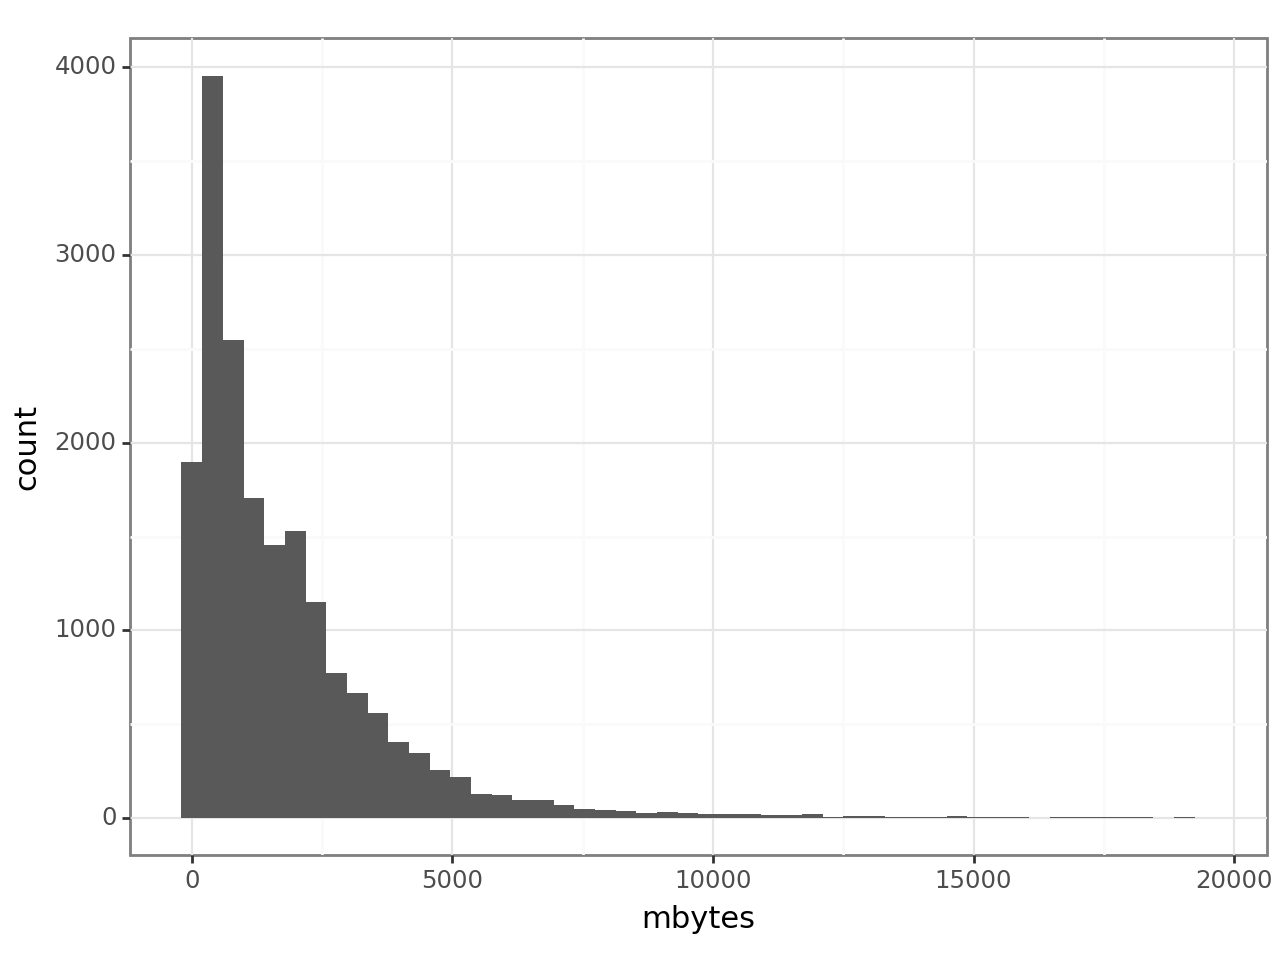

<Figure Size: (640 x 480)>

In [8]:
ggplot(joined.filter(pl.col('size')>0))+geom_histogram(aes(x='mbytes'), bins=50)

shape: (2, 2)
┌───────┬────────┐
│ done  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ false ┆ 692097 │
│ true  ┆ 18831  │
└───────┴────────┘


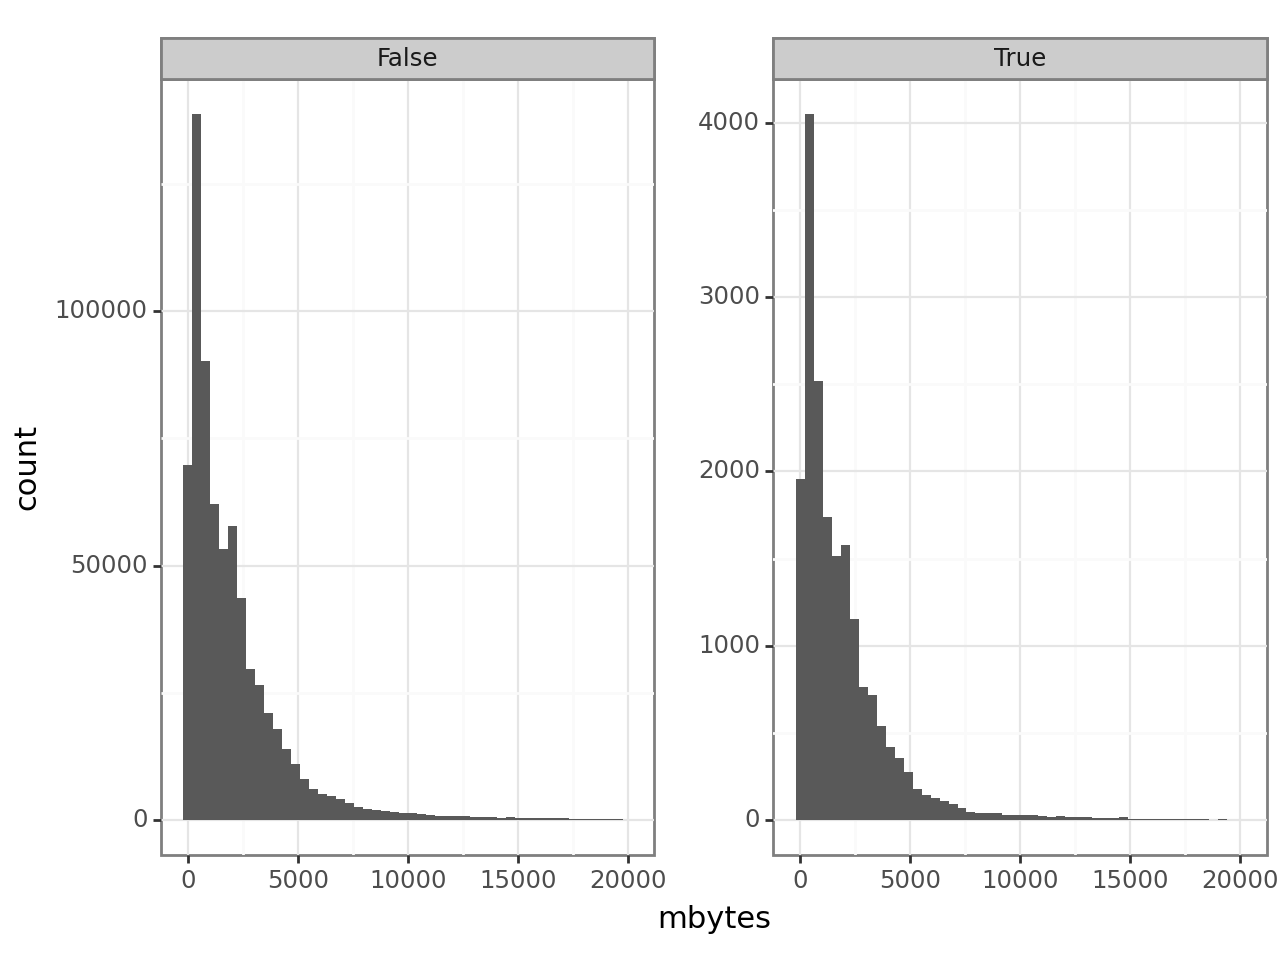

<Figure Size: (640 x 480)>

In [9]:
joined = joined.with_columns(~pl.col('size').is_null().alias('done'))
print(joined.group_by('done').len())
# ggplot(joined)+geom_density(aes(x='mbases'))#, colour='done')
# ggplot(joined.filter(pl.col('done')))+geom_histogram(aes(x='mbytes'), bins=50)
ggplot(joined)+geom_histogram(aes(x='mbytes'), bins=50)+ facet_wrap('done', scales='free_y')

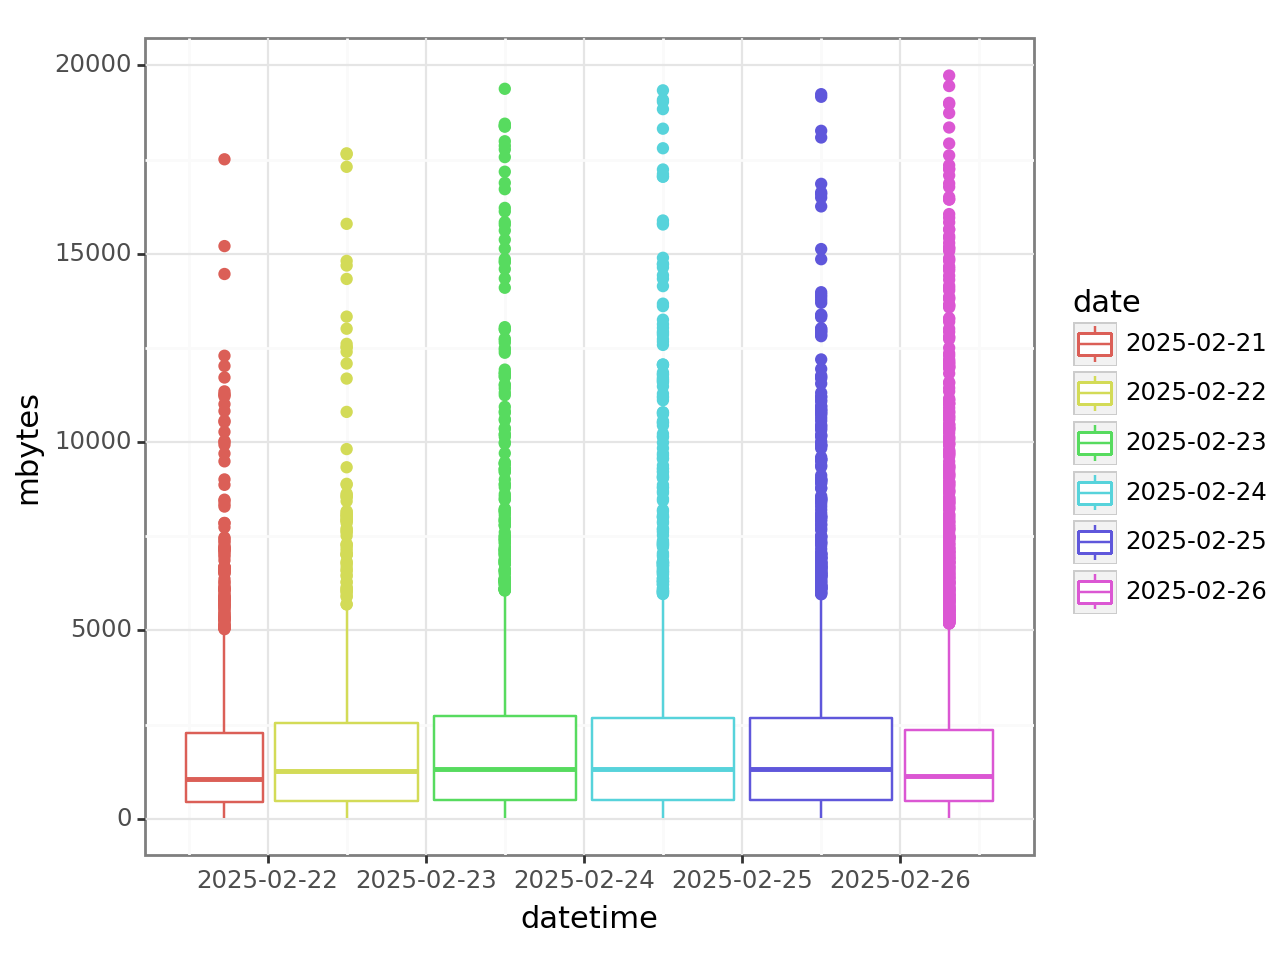

<Figure Size: (640 x 480)>

In [10]:
# Plot size vs date
ggplot(joined.filter(pl.col('done')))+geom_boxplot(aes(x='datetime', y='mbytes', colour='date'))

In [11]:
joined.filter(pl.col('done')).select('date','mbytes').group_by('date').median()

date,mbytes
str,f64
"""2025-02-23""",1310.0
"""2025-02-26""",1136.0
"""2025-02-25""",1313.0
"""2025-02-22""",1271.5
"""2025-02-24""",1327.0
"""2025-02-21""",1051.0


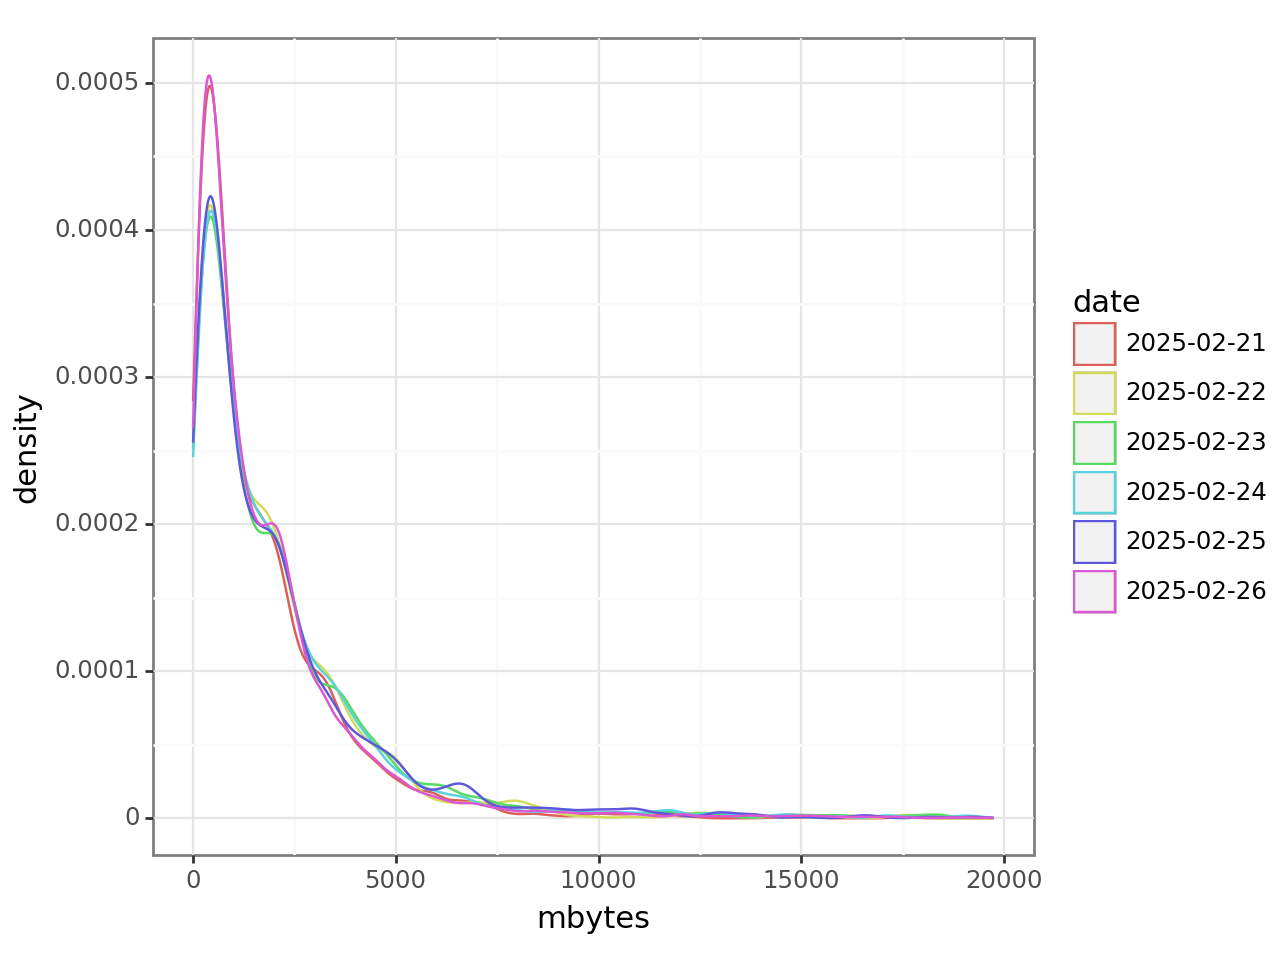

<Figure Size: (640 x 480)>

In [12]:
ggplot(joined.filter(pl.col('done')))+geom_density(aes(x='mbytes', colour='date'))